mình sẽ có thể phân tích gì dựa trên dataset này 

chất nào vượt quá tiêu chuẩn ngưỡng cho phép 

xu hướng của ô nhiễm không khí tăng hay giảm

ô nhiễm môi trường do đâu?

ô nhiễm cao nhất khi nào? (trong ngày, trong tuần, trong năm)

hiện nay nhà nước có chính sách siết chặc các xe có động cơ đốt trong vào thành phố vậy liệu động cơ đốt 
có gây ô nhiễm môi trường hay không 

dự trên kết quả phân tích thì mình sẽ làm được gì? 




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
file_name = "New_York_Air_Quality.csv"
folder_path = "dataset"
file_path = os.path.join(folder_path, file_name)

df = pd.read_csv(file_path)

C:\Users\nguye\AppData\Local\Temp\ipykernel_36780\350227357.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayOfWeek', y='AQI', data=df, order=days_order, palette='Oranges')


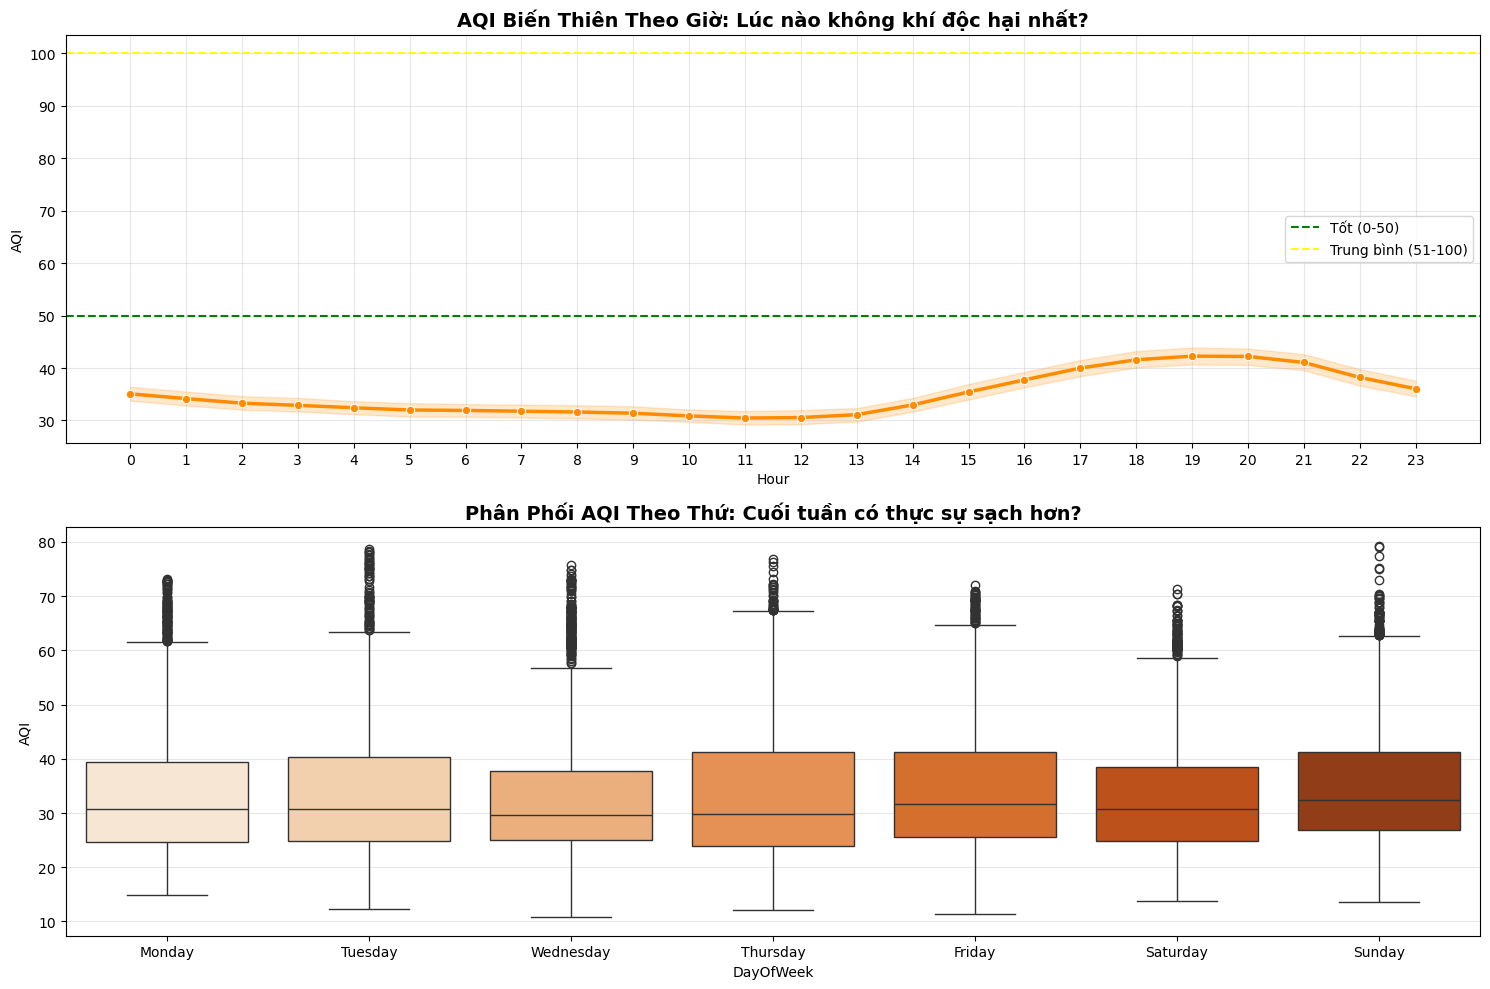

In [16]:


# 1. Đảm bảo cột Date chuẩn và tạo các cột thời gian
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(15, 10))

# --- BIỂU ĐỒ 1: AQI THEO GIỜ (Nhịp sinh hoạt) ---
plt.subplot(2, 1, 1)
sns.lineplot(x='Hour', y='AQI', data=df, marker='o', color='darkorange', linewidth=2.5)
plt.axhline(50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(100, color='yellow', linestyle='--', label='Trung bình (51-100)')
plt.title('AQI Biến Thiên Theo Giờ: Lúc nào không khí độc hại nhất?', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()

# --- BIỂU ĐỒ 2: AQI THEO THỨ (Quy luật tuần) ---
plt.subplot(2, 1, 2)
sns.boxplot(x='DayOfWeek', y='AQI', data=df, order=days_order, palette='Oranges')
plt.title('Phân Phối AQI Theo Thứ: Cuối tuần có thực sự sạch hơn?', fontsize=14, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: 8760 giờ đo) ---
• PM2.5: ⚠️ NGUY HIỂM (Vượt 2803/8760 giờ) - Giới hạn: 15 µg/m³
• PM10: ⚠️ NGUY HIỂM (Vượt 107/8760 giờ) - Giới hạn: 45 µg/m³
• NO2: ⚠️ NGUY HIỂM (Vượt 3850/8760 giờ) - Giới hạn: 25 µg/m³
• CO: ✅ AN TOÀN (Vượt 0/8760 giờ) - Giới hạn: 4000 µg/m³
• SO2: ✅ AN TOÀN (Vượt 0/8760 giờ) - Giới hạn: 40 µg/m³
• O3: ⚠️ NGUY HIỂM (Vượt 998/8760 giờ) - Giới hạn: 100 µg/m³


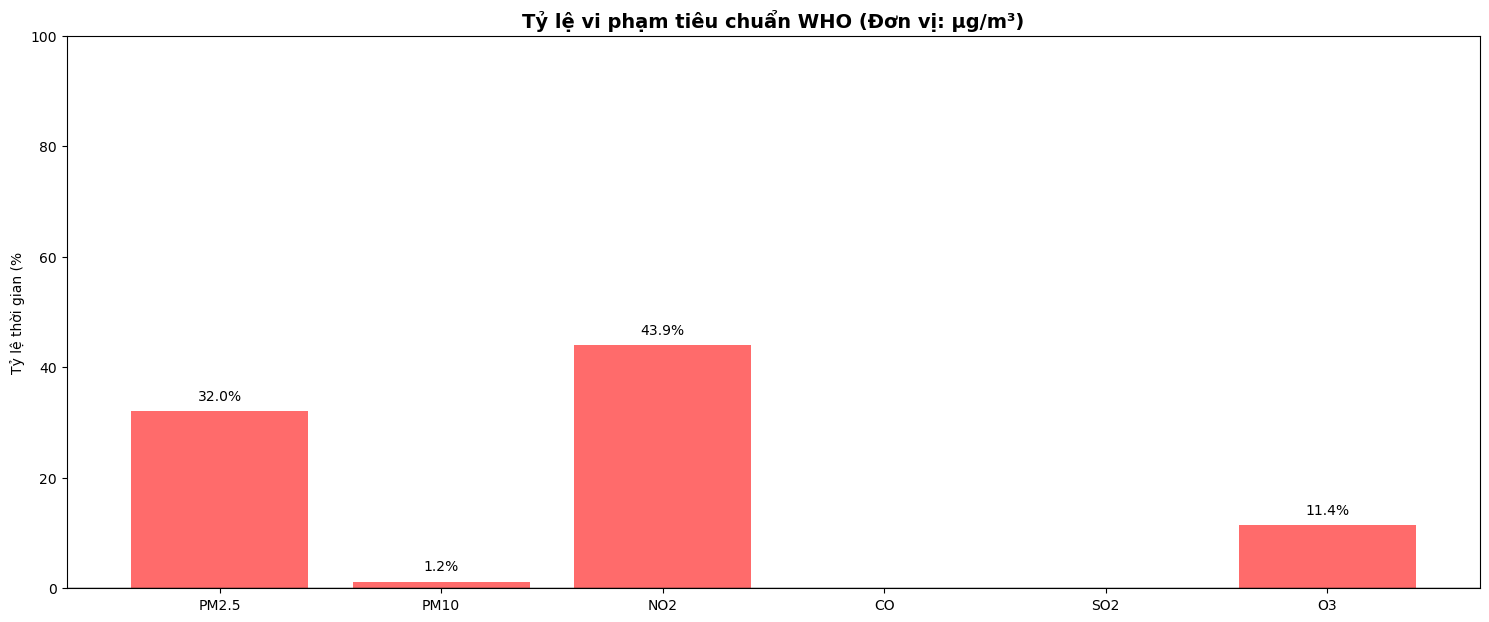

In [ ]:
# ==============================================================================
# 1. THIẾT LẬP NGƯỠNG AN TOÀN THEO WHO (µg/m³)
# ==============================================================================
thresholds_who = {
    'PM2.5': 15,    
    'PM10':  45,    
    'NO2':   25,    
    'CO':    4000,  
    'SO2':   40,    
    'O3':    100    
}

# ==============================================================================
# 2. TÍNH TOÁN & IN KẾT QUẢ (SỐ GIỜ CỤ THỂ)
# ==============================================================================
results = {} # Lưu lại để vẽ biểu đồ
total_hours = len(df) # Tổng số dòng trong dataset

print(f"--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: {total_hours} giờ đo) ---")

for pollutant, limit in thresholds_who.items():
    if pollutant in df.columns:
        # Đếm số dòng vượt ngưỡng
        exceed_count = (df[pollutant] > limit).sum()
        
        # Tính phần trăm để lưu vào biểu đồ (vẫn cần % để vẽ cột cho đẹp)
        exceed_rate = (exceed_count / total_hours) * 100
        results[pollutant] = exceed_rate
        
        # In ra màn hình theo yêu cầu của bạn: Số lượng / Tổng số
        status = "⚠️ NGUY HIỂM" if exceed_count > 0 else "✅ AN TOÀN"
        
        # Format in ra: Ví dụ "Vượt 2500/8760 giờ"
        print(f"• {pollutant}: {status} (Vượt {exceed_count}/{total_hours} giờ) - Giới hạn: {limit} µg/m³")

# ==============================================================================
# 3. VẼ BIỂU ĐỒ (ĐÃ FIX LỖI WARNING)
# ==============================================================================
plt.figure(figsize=(15, 12)) # Tăng kích thước để vẽ 2 biểu đồ

# --- BIỂU ĐỒ 1: TỶ LỆ VI PHẠM ---
plt.subplot(2, 1, 1)
bars = plt.bar(results.keys(), results.values(), color=['#ff6b6b' if v > 0 else '#4ecdc4' for v in results.values()])
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Tỷ lệ thời gian (%')
plt.title(f'Tỷ lệ vi phạm tiêu chuẩn WHO (Đơn vị: µg/m³)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{round(yval, 1)}%', ha='center')

plt.tight_layout()
plt.show()

--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: 8760 giờ đo) ---
• PM2.5: ⚠️ NGUY HIỂM (Vượt 2803/8760 giờ) - Giới hạn: 15 µg/m³
• PM10: ⚠️ NGUY HIỂM (Vượt 107/8760 giờ) - Giới hạn: 45 µg/m³
• NO2: ⚠️ NGUY HIỂM (Vượt 3850/8760 giờ) - Giới hạn: 25 µg/m³
• CO: ✅ AN TOÀN (Vượt 0/8760 giờ) - Giới hạn: 4000 µg/m³
• SO2: ✅ AN TOÀN (Vượt 0/8760 giờ) - Giới hạn: 40 µg/m³
• O3: ⚠️ NGUY HIỂM (Vượt 998/8760 giờ) - Giới hạn: 100 µg/m³


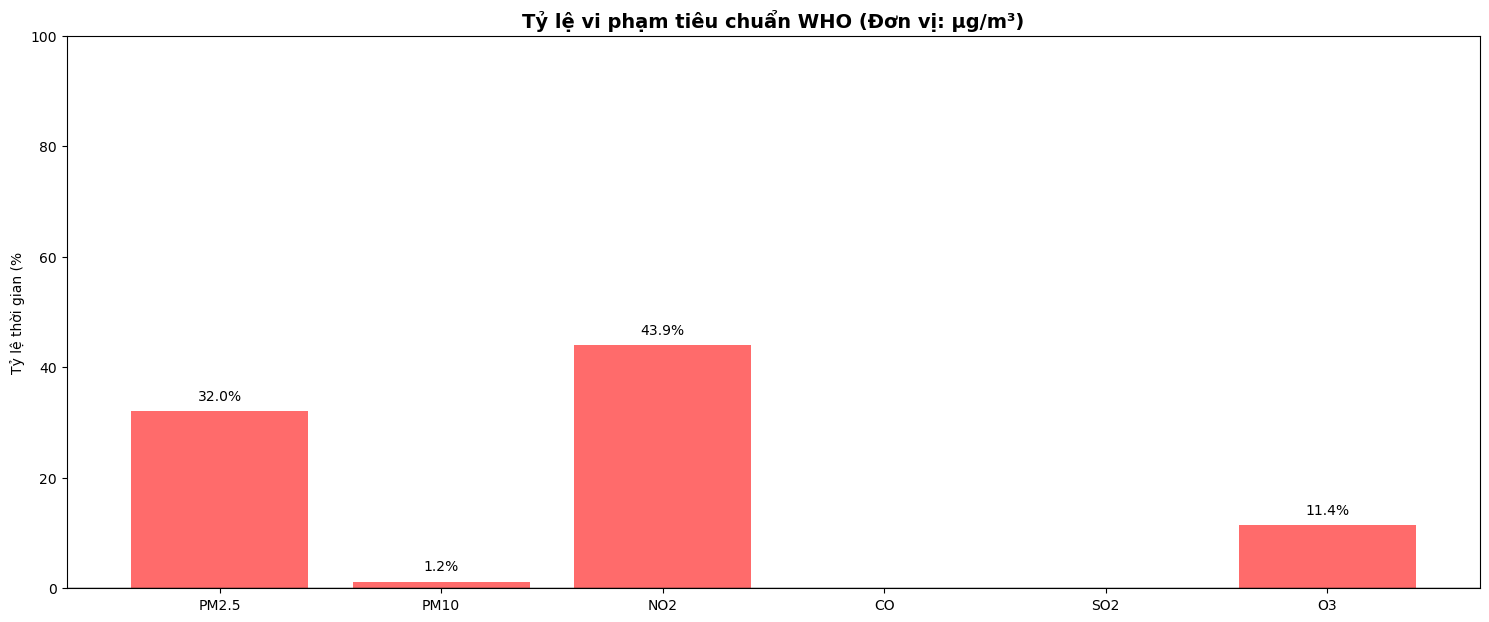

In [18]:
# ==============================================================================
# 1. THIẾT LẬP NGƯỠNG AN TOÀN THEO WHO (µg/m³)
# ==============================================================================
thresholds_who = {
    'PM2.5': 15,    
    'PM10':  45,    
    'NO2':   25,    
    'CO':    4000,  
    'SO2':   40,    
    'O3':    100    
}

# ==============================================================================
# 2. TÍNH TOÁN & IN KẾT QUẢ (SỐ GIỜ CỤ THỂ)
# ==============================================================================
results = {} # Lưu lại để vẽ biểu đồ
total_hours = len(df) # Tổng số dòng trong dataset

print(f"--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: {total_hours} giờ đo) ---")

for pollutant, limit in thresholds_who.items():
    if pollutant in df.columns:
        # Đếm số dòng vượt ngưỡng
        exceed_count = (df[pollutant] > limit).sum()
        
        # Tính phần trăm để lưu vào biểu đồ (vẫn cần % để vẽ cột cho đẹp)
        exceed_rate = (exceed_count / total_hours) * 100
        results[pollutant] = exceed_rate
        
        # In ra màn hình theo yêu cầu của bạn: Số lượng / Tổng số
        status = "⚠️ NGUY HIỂM" if exceed_count > 0 else "✅ AN TOÀN"
        
        # Format in ra: Ví dụ "Vượt 2500/8760 giờ"
        print(f"• {pollutant}: {status} (Vượt {exceed_count}/{total_hours} giờ) - Giới hạn: {limit} µg/m³")

# ==============================================================================
# 3. VẼ BIỂU ĐỒ (ĐÃ FIX LỖI WARNING)
# ==============================================================================
plt.figure(figsize=(15, 12)) # Tăng kích thước để vẽ 2 biểu đồ

# --- BIỂU ĐỒ 1: TỶ LỆ VI PHẠM ---
plt.subplot(2, 1, 1)
bars = plt.bar(results.keys(), results.values(), color=['#ff6b6b' if v > 0 else '#4ecdc4' for v in results.values()])
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Tỷ lệ thời gian (%')
plt.title(f'Tỷ lệ vi phạm tiêu chuẩn WHO (Đơn vị: µg/m³)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{round(yval, 1)}%', ha='center')



plt.tight_layout()
plt.show()

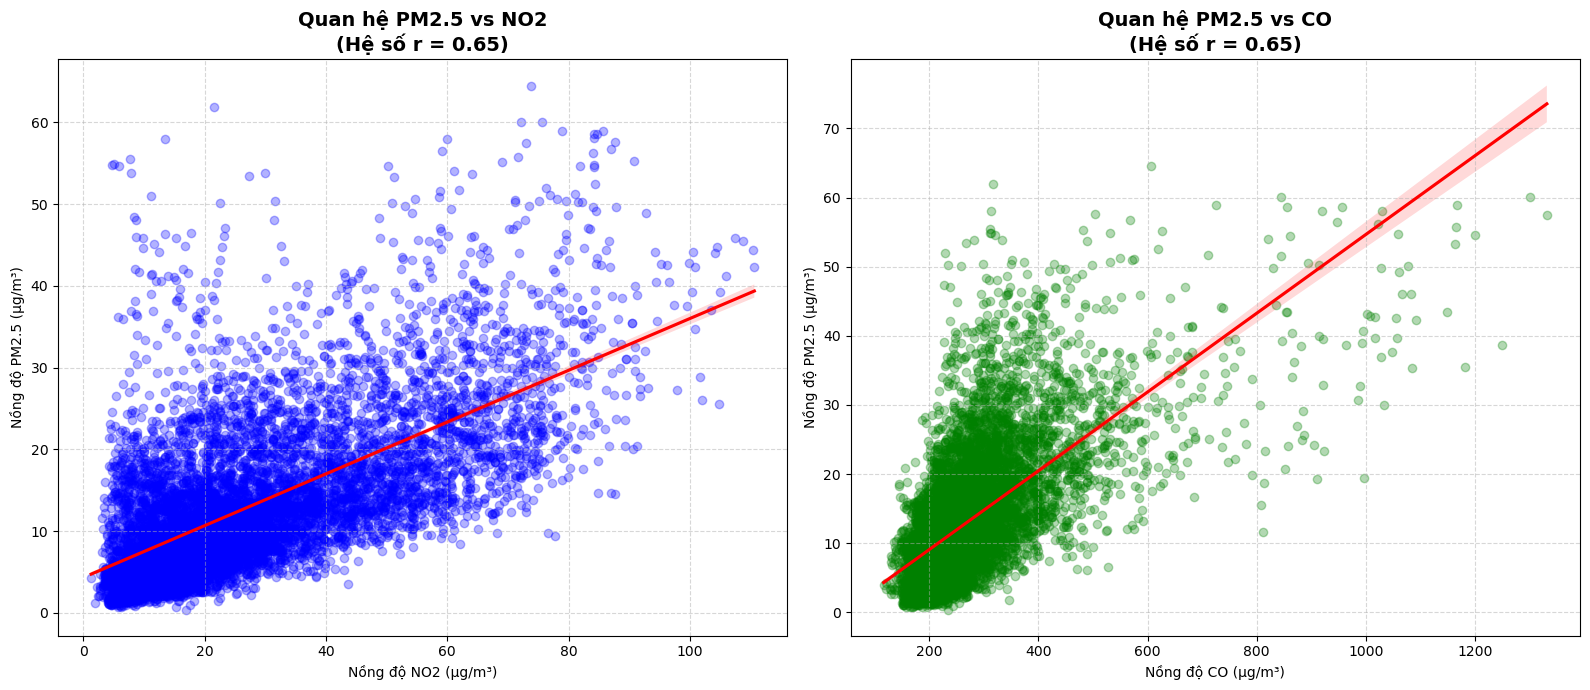

--------------------------------------------------
🕵️ KẾT LUẬN CỦA THÁM TỬ DỮ LIỆU:
🟠 NO2 (Xe tải/Bus) có quan hệ VỪA PHẢI với PM2.5 (r=0.65). -> Xe cộ đóng góp một phần lớn.
🟠 CO (Xe con/Xăng) có quan hệ VỪA PHẢI với PM2.5 (r=0.65). -> Xe cộ đóng góp một phần lớn.
--------------------------------------------------


In [20]:
# ==============================================================================
# 1. TÍNH TOÁN HỆ SỐ TƯƠNG QUAN (Correlation Coefficient - r)
# ==============================================================================
# r chạy từ -1 đến 1. 
# r càng gần 1: Hai chất này là "bạn thân" (Cùng tăng cùng giảm)
corr_no2 = df['PM2.5'].corr(df['NO2'])
corr_co = df['PM2.5'].corr(df['CO'])

# ==============================================================================
# 2. VẼ BIỂU ĐỒ SCATTER (BIỂU ĐỒ PHÂN TÁN)
# ==============================================================================
plt.figure(figsize=(16, 7))

# --- BIỂU ĐỒ 1: PM2.5 vs NO2 (Đại diện xe chạy dầu/xe tải) ---
plt.subplot(1, 2, 1)
# regplot sẽ vẽ thêm 1 đường hồi quy (đường xu hướng) để dễ nhìn
sns.regplot(x='NO2', y='PM2.5', data=df, 
            scatter_kws={'alpha':0.3, 'color':'blue'}, # Chấm mờ để thấy mật độ
            line_kws={'color':'red'}) # Đường xu hướng màu đỏ

plt.title(f'Quan hệ PM2.5 vs NO2\n(Hệ số r = {corr_no2:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Nồng độ NO2 (µg/m³)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: PM2.5 vs CO (Đại diện xe chạy xăng/xe con) ---
plt.subplot(1, 2, 2)
sns.regplot(x='CO', y='PM2.5', data=df, 
            scatter_kws={'alpha':0.3, 'color':'green'}, 
            line_kws={'color':'red'})

plt.title(f'Quan hệ PM2.5 vs CO\n(Hệ số r = {corr_co:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Nồng độ CO (µg/m³)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. MÁY TÍNH TỰ ĐỘNG KẾT LUẬN
# ==============================================================================
print("-" * 50)
print("🕵️ KẾT LUẬN CỦA THÁM TỬ DỮ LIỆU:")

def phan_tich_tuong_quan(name, r):
    if r > 0.7:
        return f"🔴 {name} có quan hệ RẤT MẠNH với PM2.5 (r={r:.2f}). -> CHẮC CHẮN do xe cộ."
    elif r > 0.4:
        return f"🟠 {name} có quan hệ VỪA PHẢI với PM2.5 (r={r:.2f}). -> Xe cộ đóng góp một phần lớn."
    elif r > 0:
        return f"🟡 {name} có quan hệ YẾU với PM2.5 (r={r:.2f}). -> Có thể do bụi xây dựng hoặc nguồn khác."
    else:
        return f"🟢 {name} đi NGƯỢC CHIỀU với PM2.5 (r={r:.2f}). -> Không phải nguyên nhân."

print(phan_tich_tuong_quan("NO2 (Xe tải/Bus)", corr_no2))
print(phan_tich_tuong_quan("CO (Xe con/Xăng)", corr_co))
print("-" * 50)

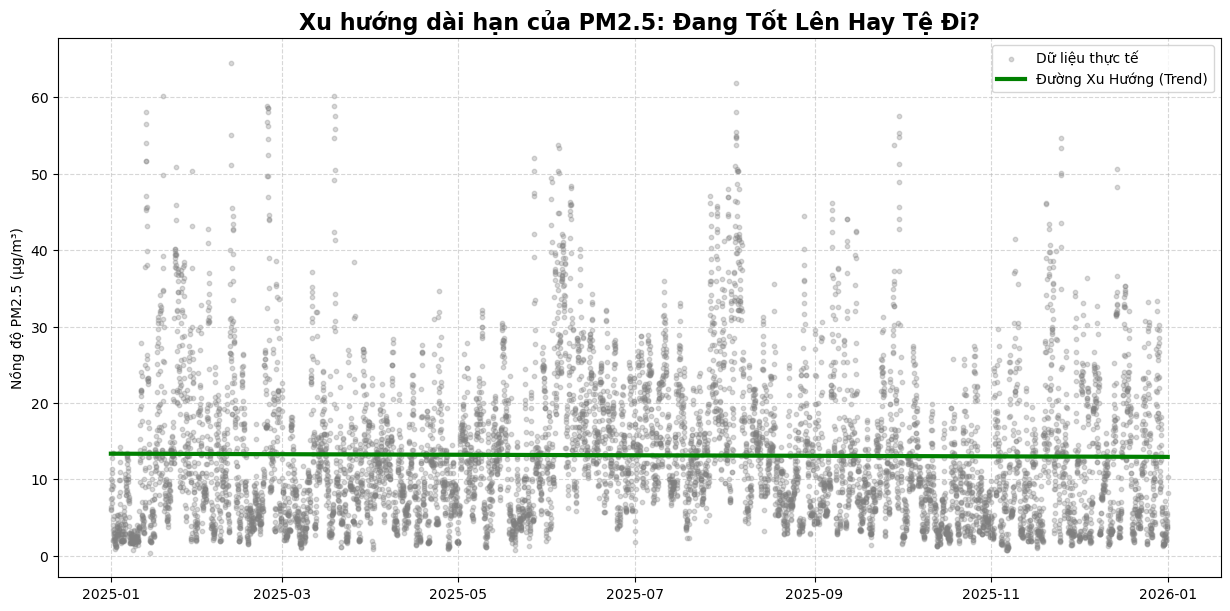

------------------------------------------------------------
📊 KẾT QUẢ PHÂN TÍCH XU HƯỚNG (PM2.5):
• Độ dốc (Slope): -0.0011 (µg/m³ mỗi ngày)
• Độ tin cậy (P-value): 0.23346
------------------------------------------------------------
👉 KẾT LUẬN: Không có xu hướng rõ ràng (Dữ liệu đi ngang hoặc biến động ngẫu nhiên).
------------------------------------------------------------


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ==============================================================================
# 1. CHUẨN BỊ DỮ LIỆU
# ==============================================================================
# Chọn biến cần soi (Ví dụ: PM2.5 hoặc NO2)
target = 'PM2.5' 

# Chuyển đổi ngày tháng sang dạng số (Ordinal) để máy tính tính toán được
# Ví dụ: Ngày 1 -> 738000, Ngày 2 -> 738001...
df['Date_Ordinal'] = pd.to_datetime(df['Date']).map(pd.Timestamp.toordinal)

# ==============================================================================
# 2. TÍNH TOÁN HỒI QUY TUYẾN TÍNH (LINEAR REGRESSION)
# ==============================================================================
# Hàm này sẽ tìm ra đường thẳng y = ax + b phù hợp nhất
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Date_Ordinal'], df[target])

# slope (Hệ số góc): Quan trọng nhất! Nó cho biết độ dốc của đường.
# p_value: Độ tin cậy. Nếu p < 0.05 nghĩa là xu hướng này là THẬT, không phải ngẫu nhiên.

# ==============================================================================
# 3. VẼ BIỂU ĐỒ TREND
# ==============================================================================
plt.figure(figsize=(15, 7))

# Vẽ dữ liệu thực tế (Mờ đi để làm nền)
plt.scatter(df['Date'], df[target], color='gray', alpha=0.3, s=10, label='Dữ liệu thực tế')

# Vẽ đường Trend (Tính toán từ phương trình y = ax + b)
y_pred = slope * df['Date_Ordinal'] + intercept
color_trend = 'red' if slope > 0 else 'green' # Đỏ nếu tăng, Xanh nếu giảm
plt.plot(df['Date'], y_pred, color=color_trend, linewidth=3, label=f'Đường Xu Hướng (Trend)')

plt.title(f'Xu hướng dài hạn của {target}: Đang Tốt Lên Hay Tệ Đi?', fontsize=16, fontweight='bold')
plt.ylabel(f'Nồng độ {target} (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# ==============================================================================
# 4. KẾT LUẬN TỰ ĐỘNG
# ==============================================================================
print("-" * 60)
print(f"📊 KẾT QUẢ PHÂN TÍCH XU HƯỚNG ({target}):")
print(f"• Độ dốc (Slope): {slope:.4f} (µg/m³ mỗi ngày)")
print(f"• Độ tin cậy (P-value): {p_value:.5f}")
print("-" * 60)

if p_value > 0.05:
    print("👉 KẾT LUẬN: Không có xu hướng rõ ràng (Dữ liệu đi ngang hoặc biến động ngẫu nhiên).")
elif slope > 0:
    print("🔴 KẾT LUẬN: TỆ ĐI! Ô nhiễm đang có xu hướng TĂNG theo thời gian.")
    print(f"   (Trung bình mỗi ngày tăng thêm {slope:.4f} µg/m³)")
else:
    print("🟢 KẾT LUẬN: TỐT LÊN! Ô nhiễm đang có xu hướng GIẢM.")
    print(f"   (Trung bình mỗi ngày giảm được {abs(slope):.4f} µg/m³)")
print("-" * 60)